# $\gamma=0.9$ — grille complète et zoom

Ce notebook rassemble les deux expériences demandées :

- `jpo_grid_s6_seed1111_g09_b10_e10_eps003_030_t700` : grille complète avec $\beta\in[0,2]$, $\epsilon\in[0.03,0.30]$ et limite de 700 s (MDP seed 1111) ;
- `jpo_low_beta_lb_s6_seed1111_g2_b4_e10_t500` : grille basse en $\beta$ avec limite de 500 s (MDP seed 1111).

La courbe noire est la frontière théorique $m=0$, c'est-à-dire

$$\beta_{\min}(\epsilon)=\frac{\gamma\,\epsilon(1-\epsilon)}{1-\gamma}.$$

Les ronds indiquent zéro violation et les croix une ou plusieurs violations. Les deux expériences utilisent le même MDP seed 1111 et tous les points sont représentés dans le même bleu ; les panneaux suffisent à distinguer les deux grilles. La convergence est vérifiée avec le critère strict `sarsop_gap < 0.1` demandé ; les points qui ne passent pas ce seuil restent visibles mais sont estompés.

In [1]:
from pathlib import Path
import json

from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch, Rectangle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPOSITORY_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'mdp.py').is_file()
)
TARGET_GAMMA = 0.9
CONVERGENCE_THRESHOLD = 0.1
DATA_DIR = REPOSITORY_ROOT / 'experiments' / 'jpo_exps' / 'revealing_check_jpo'
OUTPUT_DIR = DATA_DIR / 'fullyfreeobserved_upperbound'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT = OUTPUT_DIR / 'gamma_0p9_fullgrid_zoom.png'

SOURCES = [
    {
        'directory': 'jpo_grid_s6_seed1111_g09_b10_e10_eps003_030_t700',
        'label': 'Grille complète t700 · seed 1111',
        'short_label': 'grille complète t700',
        'color': '#2f6fbb',
    },
    {
        'directory': 'jpo_low_beta_lb_s6_seed1111_g2_b4_e10_t500',
        'label': 'Zoom t500 · seed 1111',
        'short_label': 'zoom t500',
        'color': '#2f6fbb',
    },
]

def load_gamma_slice(source):
    path = DATA_DIR / source['directory'] / 'results.json'
    payload = json.loads(path.read_text())
    points = pd.DataFrame(payload['points'])
    points = points[np.isclose(points['gamma'], TARGET_GAMMA)].copy()
    points['experiment'] = source['label']
    points['experiment_short'] = source['short_label']
    points['color'] = source['color']
    return points

frame = pd.concat([load_gamma_slice(source) for source in SOURCES], ignore_index=True)
assert len(frame) == 140
assert (frame['status'] == 'ok').all()
frame['converged'] = frame['sarsop_gap'] < CONVERGENCE_THRESHOLD
frame['violating'] = frame['violation_count'] > 0
frame.sort_values(['experiment', 'beta', 'epsilon'], inplace=True)
frame.reset_index(drop=True, inplace=True)
frame.shape

(140, 52)

## Vérification de la convergence

Le `sarsop_gap` est le certificat final $U-L$ du solveur. Le seuil ci-dessous est strict : un point avec un gap exactement égal à 0.1 serait classé non convergé. `root_gap` est également reporté à titre de contrôle.

In [2]:
convergence_summary = (
    frame.groupby(['experiment', 'experiment_short'], sort=False)
    .agg(
        points=('point_id', 'size'),
        converged_points=('converged', 'sum'),
        max_sarsop_gap=('sarsop_gap', 'max'),
        max_root_gap=('root_gap', 'max'),
        max_time_stops=('solver_stop_reason', lambda values: int((values == 'max_time').sum())),
    )
    .reset_index()
)
convergence_summary['non_converged_points'] = (
    convergence_summary['points'] - convergence_summary['converged_points']
)
convergence_summary['all_gaps_below_0.1'] = (
    convergence_summary['non_converged_points'] == 0
)
display(convergence_summary[[
    'experiment_short', 'points', 'converged_points', 'non_converged_points',
    'max_sarsop_gap', 'max_root_gap', 'max_time_stops', 'all_gaps_below_0.1',
]].round(6))

non_converged = frame[~frame['converged']].copy()
if non_converged.empty:
    display(Markdown('**Résultat :** tous les points passent le seuil strict $<0.1$.'))
else:
    counts = non_converged.groupby('experiment_short', sort=False).size()
    details = '; '.join(f'{name}: {count}' for name, count in counts.items())
    display(Markdown(
        f'**Résultat : le contrôle échoue.** {len(non_converged)}/140 points ont '
        f'`sarsop_gap >= 0.1` ({details}). Ils sont estompés dans la figure.'
    ))
    display(
        non_converged[[
            'experiment_short', 'point_id', 'beta', 'epsilon', 'sarsop_gap',
            'root_gap', 'solver_stop_reason', 'violation_count',
        ]]
        .sort_values('sarsop_gap', ascending=False)
        .head(12)
        .round(6)
    )

,experiment_short,points,converged_points,non_converged_points,max_sarsop_gap,max_root_gap,max_time_stops,all_gaps_below_0.1
0,grille complète t700,100,11,89,1.461096,1.461096,95,False
1,zoom t500,40,35,5,0.175349,0.181123,23,False


**Résultat : le contrôle échoue.** 94/140 points ont `sarsop_gap >= 0.1` (grille complète t700: 89; zoom t500: 5). Ils sont estompés dans la figure.

,experiment_short,point_id,beta,epsilon,sarsop_gap,root_gap,solver_stop_reason,violation_count
53,grille complète t700,g0_b05_e03,1.111111,0.12,1.461096,1.461096,max_time,0
55,grille complète t700,g0_b05_e05,1.111111,0.18,1.456393,1.456393,max_time,0
57,grille complète t700,g0_b05_e07,1.111111,0.24,1.438382,1.438382,max_time,0
50,grille complète t700,g0_b05_e00,1.111111,0.03,1.381733,1.381733,max_time,0
56,grille complète t700,g0_b05_e06,1.111111,0.21,1.374030,1.374030,max_time,0
52,grille complète t700,g0_b05_e02,1.111111,0.09,1.346586,1.346586,max_time,0
64,grille complète t700,g0_b06_e04,1.333333,0.15,1.334186,1.334186,max_time,0
39,grille complète t700,g0_b03_e09,0.666667,0.30,1.324293,1.324293,max_time,0
61,grille complète t700,g0_b06_e01,1.333333,0.06,1.321107,1.321107,max_time,0
65,grille complète t700,g0_b06_e05,1.333333,0.18,1.317917,1.317917,max_time,0


## Courbe $\beta_{\min}(\epsilon)$, grille complète et zoom

Le panneau du haut montre uniquement l'expérience `t500` sur $\epsilon\in[0,0.10]$ et $\beta\in[0,0.30]$. Le panneau inférieur montre uniquement la grille complète `t700` sur $\epsilon\in[0,0.30]$ et $\beta\in[0,2]$. Le rectangle gris matérialise la fenêtre du panneau supérieur.

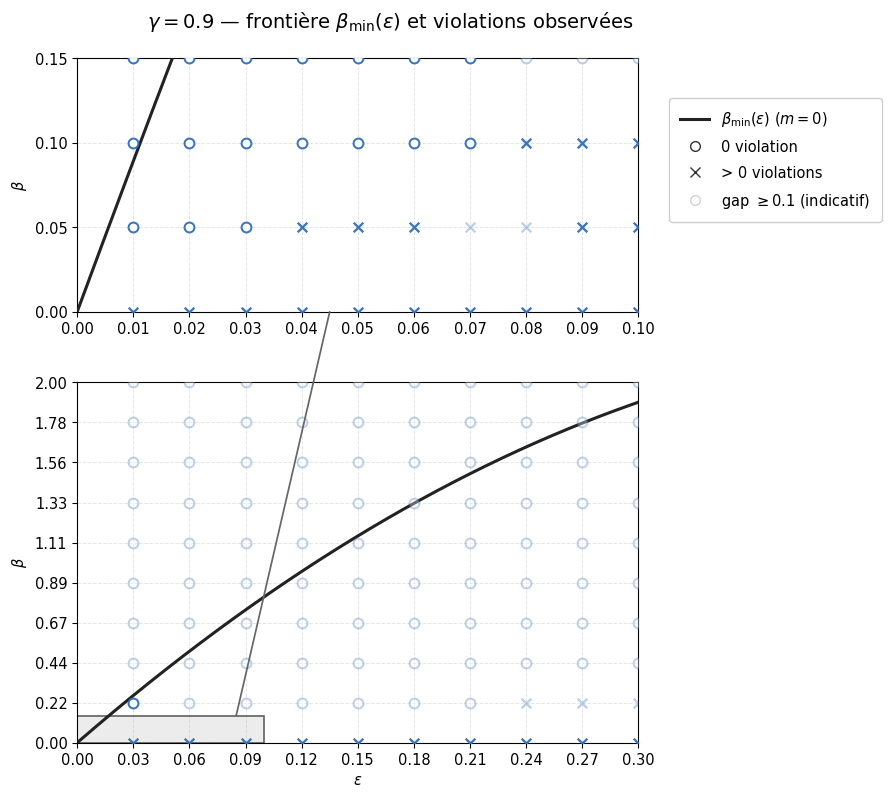

Figure sauvegardée dans `experiments/jpo_exps/revealing_check_jpo/fullyfreeobserved_upperbound/gamma_0p9_fullgrid_zoom.png`.

In [3]:
def beta_min(epsilon, gamma=TARGET_GAMMA):
    epsilon = np.asarray(epsilon, dtype=float)
    return gamma * epsilon * (1.0 - epsilon) / (1.0 - gamma)

def add_grid_points(ax, sources):
    for source in sources:
        subset = frame[frame['experiment'] == source['label']]
        for converged, alpha in [(False, 0.32), (True, 0.95)]:
            quality = subset[subset['converged'] == converged]
            zero = quality[~quality['violating']]
            positive = quality[quality['violating']]
            ax.scatter(
                zero['epsilon'], zero['beta'], s=50, marker='o',
                facecolors='white', edgecolors=source['color'], linewidths=1.45,
                alpha=alpha, zorder=4,
            )
            ax.scatter(
                positive['epsilon'], positive['beta'], s=48, marker='x',
                color=source['color'], linewidths=1.65, alpha=alpha, zorder=5,
            )

epsilon_dense = np.linspace(0.0, 0.3, 1200)
with plt.rc_context({
    'font.size': 10.5,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.grid': True,
    'grid.alpha': 0.32,
    'grid.linestyle': '--',
    'grid.linewidth': 0.7,
}):
    fig = plt.figure(figsize=(9.2, 8.1))
    grid = fig.add_gridspec(2, 1, height_ratios=[0.95, 1.35], hspace=0.23)
    ax_zoom = fig.add_subplot(grid[0])
    ax_full = fig.add_subplot(grid[1])

    for ax in (ax_zoom, ax_full):
        ax.plot(
            epsilon_dense, beta_min(epsilon_dense),
            color='#222222', linewidth=2.2, zorder=3,
        )
        ax.set_ylabel(r'$\beta$')

    add_grid_points(ax_zoom, [SOURCES[1]])
    add_grid_points(ax_full, [SOURCES[0]])

    zoom_xlim = (0.0, 0.10)
    zoom_ylim = (0.0, 0.15)
    ax_zoom.set_xlim(*zoom_xlim)
    ax_zoom.set_ylim(*zoom_ylim)
    ax_zoom.set_xticks(np.arange(0.0, 0.101, 0.01))
    ax_zoom.set_yticks(np.arange(0.0, 0.151, 0.05))
    #ax_zoom.set_title(r'Expérience t500 — faible $\epsilon$ et faible $\beta$', pad=8)

    ax_full.set_xlim(0.0, 0.30)
    ax_full.set_ylim(0.0, 2.0)
    full_grid = frame[frame['experiment'] == SOURCES[0]['label']]
    full_epsilons = np.sort(full_grid['epsilon'].unique())
    full_betas = np.sort(full_grid['beta'].unique())
    full_x_ticks = np.insert(full_epsilons, 0, 0.0)
    ax_full.set_xticks(full_x_ticks, [f'{value:.2f}' for value in full_x_ticks])
    ax_full.set_yticks(full_betas, [f'{value:.2f}' for value in full_betas])
    ax_full.set_xlabel(r'$\epsilon$')
    #ax_full.set_title('Expérience t700 — grille complète', loc='right', pad=8)

    zoom_rectangle = Rectangle(
        (zoom_xlim[0], zoom_ylim[0]),
        zoom_xlim[1] - zoom_xlim[0], zoom_ylim[1] - zoom_ylim[0],
        facecolor=(0.55, 0.55, 0.55, 0.16),
        edgecolor='#666666', linewidth=1.25, zorder=2,
    )
    ax_full.add_patch(zoom_rectangle)

    connector = ConnectionPatch(
        xyA=(0.085, zoom_ylim[1]), coordsA='data', axesA=ax_full,
        xyB=(0.045, zoom_ylim[0]), coordsB='data', axesB=ax_zoom,
        color='#666666', linewidth=1.25,
        clip_on=False, zorder=1,
    )
    fig.add_artist(connector)

    legend_handles = [
        Line2D([0], [0], color='#222222', lw=2.2,
               label=r'$\beta_{\min}(\epsilon)$ ($m=0$)'),
        Line2D([0], [0], marker='o', linestyle='None', markersize=7,
               markerfacecolor='white', markeredgecolor='#333333', label='0 violation'),
        Line2D([0], [0], marker='x', linestyle='None', markersize=7,
               color='#333333', label='> 0 violations'),
        Line2D([0], [0], marker='o', linestyle='None', markersize=7,
               markerfacecolor='none', markeredgecolor='#777777', alpha=0.32,
               label=r'gap $\geq 0.1$ (indicatif)'),
    ]
    fig.legend(
        handles=legend_handles, loc='upper left', bbox_to_anchor=(0.735, 0.885),
        frameon=True, framealpha=0.96, borderpad=0.8, labelspacing=0.75,
    )
    fig.suptitle(
        r'$\gamma=0.9$ — frontière $\beta_{\min}(\epsilon)$ et violations observées',
        x=0.44, y=0.985, fontsize=14,
    )
    fig.subplots_adjust(left=0.10, right=0.71, bottom=0.08, top=0.925)
    fig.savefig(OUTPUT, dpi=220, bbox_inches='tight')
    plt.show()

display(Markdown(f'Figure sauvegardée dans `{OUTPUT.relative_to(REPOSITORY_ROOT)}`.'))

## Variante compacte — zoom à gauche, légende à droite

Cette seconde composition reprend l'organisation de la figure de référence : le panneau agrandi occupe seulement la partie supérieure gauche, tandis que la grille complète utilise toute la largeur.

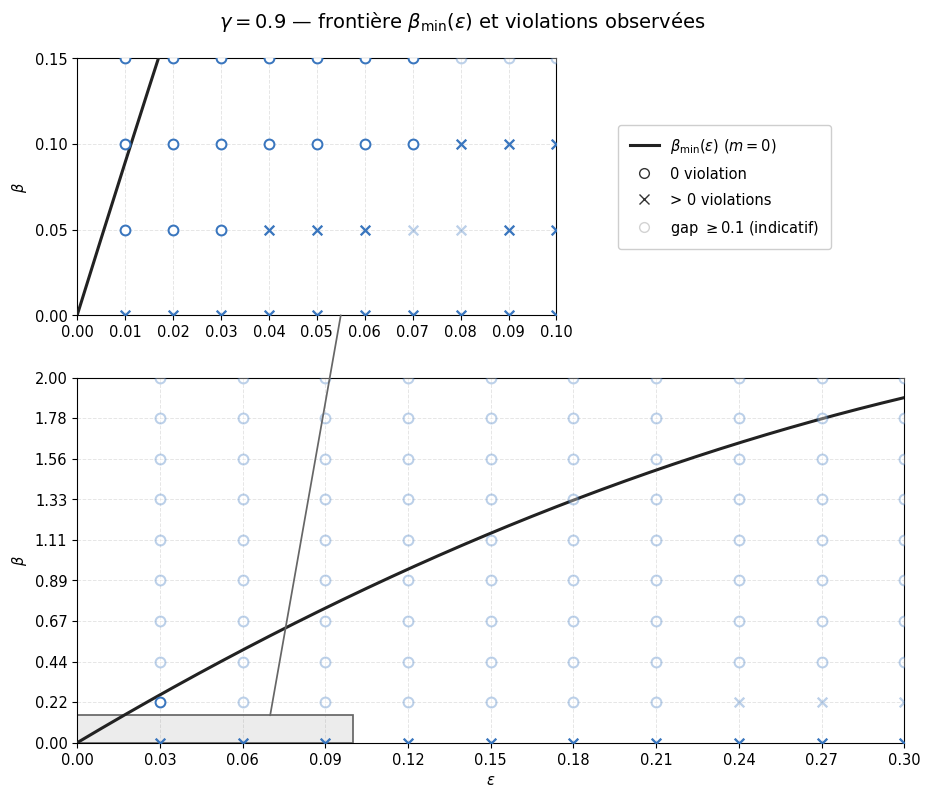

Variante compacte sauvegardée dans `experiments/jpo_exps/revealing_check_jpo/fullyfreeobserved_upperbound/gamma_0p9_fullgrid_zoom_compact.png`.

In [4]:
OUTPUT_COMPACT = OUTPUT_DIR / 'gamma_0p9_fullgrid_zoom_compact.png'

with plt.rc_context({
    'font.size': 10.5,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.grid': True,
    'grid.alpha': 0.32,
    'grid.linestyle': '--',
    'grid.linewidth': 0.7,
}):
    fig_compact = plt.figure(figsize=(9.4, 8.1))
    compact_grid = fig_compact.add_gridspec(
        2, 2, width_ratios=[0.62, 0.38], height_ratios=[0.95, 1.35],
        hspace=0.20, wspace=0.14,
    )
    ax_zoom_compact = fig_compact.add_subplot(compact_grid[0, 0])
    ax_legend = fig_compact.add_subplot(compact_grid[0, 1])
    ax_full_compact = fig_compact.add_subplot(compact_grid[1, :])
    ax_legend.axis('off')

    for ax in (ax_zoom_compact, ax_full_compact):
        ax.plot(
            epsilon_dense, beta_min(epsilon_dense),
            color='#222222', linewidth=2.2, zorder=3,
        )
        ax.set_ylabel(r'$\beta$')

    add_grid_points(ax_zoom_compact, [SOURCES[1]])
    add_grid_points(ax_full_compact, [SOURCES[0]])

    ax_zoom_compact.set_xlim(*zoom_xlim)
    ax_zoom_compact.set_ylim(*zoom_ylim)
    ax_zoom_compact.set_xticks(np.arange(0.0, 0.101, 0.01))
    ax_zoom_compact.set_yticks(np.arange(0.0, 0.151, 0.05))

    ax_full_compact.set_xlim(0.0, 0.30)
    ax_full_compact.set_ylim(0.0, 2.0)
    ax_full_compact.set_xticks(
        full_x_ticks, [f'{value:.2f}' for value in full_x_ticks],
    )
    ax_full_compact.set_yticks(
        full_betas, [f'{value:.2f}' for value in full_betas],
    )
    ax_full_compact.set_xlabel(r'$\epsilon$')

    compact_rectangle = Rectangle(
        (zoom_xlim[0], zoom_ylim[0]),
        zoom_xlim[1] - zoom_xlim[0], zoom_ylim[1] - zoom_ylim[0],
        facecolor=(0.55, 0.55, 0.55, 0.16),
        edgecolor='#666666', linewidth=1.25, zorder=2,
    )
    ax_full_compact.add_patch(compact_rectangle)

    compact_connector = ConnectionPatch(
        xyA=(0.070, zoom_ylim[1]), coordsA='data', axesA=ax_full_compact,
        xyB=(0.055, zoom_ylim[0]), coordsB='data', axesB=ax_zoom_compact,
        color='#666666', linewidth=1.25,
        clip_on=False, zorder=1,
    )
    fig_compact.add_artist(compact_connector)

    ax_legend.legend(
        handles=legend_handles, loc='center left',
        frameon=True, framealpha=0.96, borderpad=0.8, labelspacing=0.75,
    )
    fig_compact.suptitle(
        r'$\gamma=0.9$ — frontière $\beta_{\min}(\epsilon)$ et violations observées',
        x=0.50, y=0.985, fontsize=14,
    )
    fig_compact.subplots_adjust(
        left=0.09, right=0.97, bottom=0.08, top=0.925,
    )
    fig_compact.savefig(OUTPUT_COMPACT, dpi=220, bbox_inches='tight')
    plt.show()

display(Markdown(
    f'Variante compacte sauvegardée dans `{OUTPUT_COMPACT.relative_to(REPOSITORY_ROOT)}`.'
))

## Frontière ajustée par la valeur du MDP pleinement observé

La valeur $V^{\mathrm{FO}}(\mu_0)$ est relue dans chaque fichier `jpo/training.json`. La nouvelle frontière utilise la même distribution initiale uniforme que les objectifs rapportés :

$$\beta_{\min}^{\mathrm{MDP}}(\epsilon)=\gamma V^{\mathrm{FO}}(\mu_0)\,\epsilon(1-\epsilon).$$

Les **140 points** donnent tous $V^{\mathrm{FO}}(\mu_0)=5.129459753872$, donc $\gamma V^{\mathrm{FO}}(\mu_0)=4.616513778485$ (résidu maximal : `9.137e-09`).

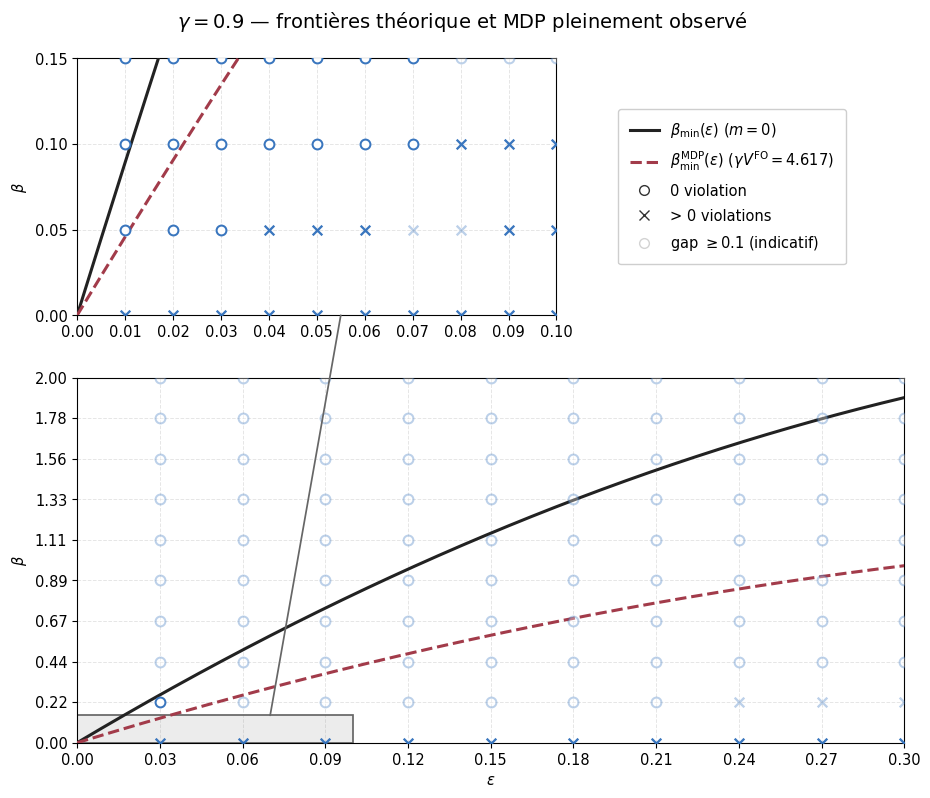

Figure avec frontière MDP sauvegardée dans `experiments/jpo_exps/revealing_check_jpo/fullyfreeobserved_upperbound/gamma_0p9_fullgrid_zoom_compact_mdp.png`.

In [5]:
fully_observed_records = []
for source in SOURCES:
    source_points = frame[frame['experiment'] == source['label']]
    for point_id in source_points['point_id']:
        training_path = (
            DATA_DIR / source['directory'] / 'runs' / point_id / 'jpo' / 'training.json'
        )
        diagnostics = json.loads(training_path.read_text())
        training = diagnostics['training']
        history = training['history']
        assert history and history[0]['iteration'] == 0
        assert training['initial_upper_bound'] == 'fully_observable'
        assert np.isclose(diagnostics['model']['gamma'], TARGET_GAMMA)
        fully_observed_records.append({
            'experiment': source['short_label'],
            'point_id': point_id,
            'value': history[0]['initial_upper_objective'],
            'residual': training['initial_upper_residual'],
            'iterations': training['initial_upper_iterations'],
        })

fully_observed = pd.DataFrame(fully_observed_records)
assert len(fully_observed) == len(frame) == 140
assert fully_observed['residual'].max() <= 1e-8
assert np.allclose(
    fully_observed['value'], fully_observed['value'].iloc[0],
    rtol=0.0, atol=1e-12,
)
V_FULLY_OBSERVED = float(fully_observed['value'].iloc[0])
MDP_COEFFICIENT = TARGET_GAMMA * V_FULLY_OBSERVED

def beta_min_mdp(epsilon, value=V_FULLY_OBSERVED, gamma=TARGET_GAMMA):
    epsilon = np.asarray(epsilon, dtype=float)
    return gamma * value * epsilon * (1.0 - epsilon)

display(Markdown(
    f'Les **{len(fully_observed)} points** donnent tous '
    rf'$V^{{\mathrm{{FO}}}}(\mu_0)={V_FULLY_OBSERVED:.12f}$, donc '
    rf'$\gamma V^{{\mathrm{{FO}}}}(\mu_0)={MDP_COEFFICIENT:.12f}$ '
    f'(résidu maximal : `{fully_observed["residual"].max():.3e}`).'
))

OUTPUT_COMPACT_MDP = OUTPUT_DIR / 'gamma_0p9_fullgrid_zoom_compact_mdp.png'
MDP_CURVE_COLOR = '#a23b4a'

with plt.rc_context({
    'font.size': 10.5,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.grid': True,
    'grid.alpha': 0.32,
    'grid.linestyle': '--',
    'grid.linewidth': 0.7,
}):
    fig_mdp = plt.figure(figsize=(9.4, 8.1))
    mdp_grid = fig_mdp.add_gridspec(
        2, 2, width_ratios=[0.62, 0.38], height_ratios=[0.95, 1.35],
        hspace=0.20, wspace=0.14,
    )
    ax_zoom_mdp = fig_mdp.add_subplot(mdp_grid[0, 0])
    ax_legend_mdp = fig_mdp.add_subplot(mdp_grid[0, 1])
    ax_full_mdp = fig_mdp.add_subplot(mdp_grid[1, :])
    ax_legend_mdp.axis('off')

    for ax in (ax_zoom_mdp, ax_full_mdp):
        ax.plot(
            epsilon_dense, beta_min(epsilon_dense),
            color='#222222', linewidth=2.2, zorder=3,
        )
        ax.plot(
            epsilon_dense, beta_min_mdp(epsilon_dense),
            color=MDP_CURVE_COLOR, linewidth=2.2, linestyle='--', zorder=3,
        )
        ax.set_ylabel(r'$\beta$')

    add_grid_points(ax_zoom_mdp, [SOURCES[1]])
    add_grid_points(ax_full_mdp, [SOURCES[0]])

    ax_zoom_mdp.set_xlim(*zoom_xlim)
    ax_zoom_mdp.set_ylim(*zoom_ylim)
    ax_zoom_mdp.set_xticks(np.arange(0.0, 0.101, 0.01))
    ax_zoom_mdp.set_yticks(np.arange(0.0, 0.151, 0.05))

    ax_full_mdp.set_xlim(0.0, 0.30)
    ax_full_mdp.set_ylim(0.0, 2.0)
    ax_full_mdp.set_xticks(
        full_x_ticks, [f'{value:.2f}' for value in full_x_ticks],
    )
    ax_full_mdp.set_yticks(
        full_betas, [f'{value:.2f}' for value in full_betas],
    )
    ax_full_mdp.set_xlabel(r'$\epsilon$')

    mdp_rectangle = Rectangle(
        (zoom_xlim[0], zoom_ylim[0]),
        zoom_xlim[1] - zoom_xlim[0], zoom_ylim[1] - zoom_ylim[0],
        facecolor=(0.55, 0.55, 0.55, 0.16),
        edgecolor='#666666', linewidth=1.25, zorder=2,
    )
    ax_full_mdp.add_patch(mdp_rectangle)

    mdp_connector = ConnectionPatch(
        xyA=(0.070, zoom_ylim[1]), coordsA='data', axesA=ax_full_mdp,
        xyB=(0.055, zoom_ylim[0]), coordsB='data', axesB=ax_zoom_mdp,
        color='#666666', linewidth=1.25,
        clip_on=False, zorder=1,
    )
    fig_mdp.add_artist(mdp_connector)

    mdp_legend_handles = [
        Line2D([0], [0], color='#222222', lw=2.2,
               label=r'$\beta_{\min}(\epsilon)$ ($m=0$)'),
        Line2D([0], [0], color=MDP_CURVE_COLOR, lw=2.2, linestyle='--',
               label=(r'$\beta_{\min}^{\mathrm{MDP}}(\epsilon)$ '
                      rf'($\gamma V^{{\mathrm{{FO}}}}={MDP_COEFFICIENT:.3f}$)')),
        Line2D([0], [0], marker='o', linestyle='None', markersize=7,
               markerfacecolor='white', markeredgecolor='#333333', label='0 violation'),
        Line2D([0], [0], marker='x', linestyle='None', markersize=7,
               color='#333333', label='> 0 violations'),
        Line2D([0], [0], marker='o', linestyle='None', markersize=7,
               markerfacecolor='none', markeredgecolor='#777777', alpha=0.32,
               label=r'gap $\geq 0.1$ (indicatif)'),
    ]
    ax_legend_mdp.legend(
        handles=mdp_legend_handles, loc='center left',
        frameon=True, framealpha=0.96, borderpad=0.8, labelspacing=0.70,
    )
    fig_mdp.suptitle(
        r'$\gamma=0.9$ — frontières théorique et MDP pleinement observé',
        x=0.50, y=0.985, fontsize=14,
    )
    fig_mdp.subplots_adjust(
        left=0.09, right=0.97, bottom=0.08, top=0.925,
    )
    fig_mdp.savefig(OUTPUT_COMPACT_MDP, dpi=220, bbox_inches='tight')
    plt.show()

display(Markdown(
    f'Figure avec frontière MDP sauvegardée dans '
    f'`{OUTPUT_COMPACT_MDP.relative_to(REPOSITORY_ROOT)}`.'
))

## Lecture

La frontière MDP remplace le majorant uniforme $1/(1-\gamma)$ par la valeur pleinement observée $V^{\mathrm{FO}}(\mu_0)$, tout en conservant le facteur $\gamma$.

Les deux grilles utilisent le même MDP seed 1111 : le panneau complet couvre la frontière $m=0$ jusqu'à $\epsilon=0.30$, tandis que `t500` raffine la zone de très faibles $\beta$. Les marqueurs pâles signalent les politiques dont le certificat SARSOP reste supérieur ou égal à 0.1 ; leurs violations sont descriptives de la politique retournée, sans certification de proximité à l'optimum.